1.  Load the iris dataset from sklearn (1 Mark)




In [1]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

2.  Split the dataset into train and test sets in a ratio of 70%-30%(1 Mark)

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score , precision_score, recall_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

3.  Implement the perceptron algorithm from scratch and fit the perceptron model on the training set. Terminate the learning of each classifier when the number of misclassified samples stops reducing any further. (Hint 1: How many perceptron classifiers do we need? Hint 2: Two different models output 1 who wins?) (8 Marks)

In [34]:
class CustomPerceptron:
    def __init__(self, feature_count, learning_rate):
        """
        Initialize perceptron weights and learning rate
        """
        self.learning_rate = learning_rate

        self.weights = np.zeros(feature_count + 1)

    def activation_function(self, value):
        """
        Step activation function
        """
        return 1 if value >= 0 else -1

    def compute_output(self, x):
        """
        Forward pass: compute perceptron output
        """
        x_bias = np.append(x, 1)  #bias
        activation_value = np.dot(self.weights, x_bias)
        return self.activation_function(activation_value)

    def compute_error(self, prediction, target):
        """
        Error function: product of prediction and target
        """
        return prediction * target

    def update_weights(self, error, x, target):
        """
        Update weights only if misclassification occurs
        """
        if error < 0:
            x_bias = np.append(x, 1)
            self.weights += self.learning_rate * target * x_bias


In [19]:
learning_rate = 0.3

class_labels = np.unique(y_train)

#store misclassification history /class
error_history = {cls: [] for cls in class_labels}

#store trained perceptrons
trained_models = {}


In [35]:
for current_class in class_labels:

    print(f"\nTraining perceptron for class {current_class}")

    #create binary labels for One-Vs-Rest
    binary_targets = np.where(y_train == current_class, 1, -1)

    #Initialize perceptron
    perceptron = CustomPerceptron(
        feature_count=X_train.shape[1],
        learning_rate=learning_rate
    )

    best_error = np.inf
    no_improvement_epochs = 0
    epoch_counter = 0

    while True:
        epoch_errors = 0

        for i in range(len(X_train)):
            prediction = perceptron.compute_output(X_train[i])
            error = perceptron.compute_error(prediction, binary_targets[i])

            if error < 0:
                epoch_errors += 1

            perceptron.update_weights(error, X_train[i], binary_targets[i])

        epoch_counter += 1
        error_history[current_class].append(epoch_errors)

        print(f"Class {current_class} | Epoch {epoch_counter} | Misclassified: {epoch_errors}")

        #Perfect classification
        if epoch_errors == 0:
            print(f"Class {current_class} converged with zero misclassifications")
            break

        #Improvement check
        if epoch_errors < best_error:
            best_error = epoch_errors
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1

        #Stop if no improvement for 8 epochs
        if no_improvement_epochs >= 8:
            print(f"Stopping training for class {current_class} (no improvement)")
            break

    trained_models[current_class] = perceptron



Training perceptron for class 0
Class 0 | Epoch 1 | Misclassified: 2
Class 0 | Epoch 2 | Misclassified: 0
Class 0 converged with zero misclassifications

Training perceptron for class 1
Class 1 | Epoch 1 | Misclassified: 36
Class 1 | Epoch 2 | Misclassified: 38
Class 1 | Epoch 3 | Misclassified: 39
Class 1 | Epoch 4 | Misclassified: 34
Class 1 | Epoch 5 | Misclassified: 39
Class 1 | Epoch 6 | Misclassified: 37
Class 1 | Epoch 7 | Misclassified: 34
Class 1 | Epoch 8 | Misclassified: 37
Class 1 | Epoch 9 | Misclassified: 31
Class 1 | Epoch 10 | Misclassified: 34
Class 1 | Epoch 11 | Misclassified: 31
Class 1 | Epoch 12 | Misclassified: 30
Class 1 | Epoch 13 | Misclassified: 32
Class 1 | Epoch 14 | Misclassified: 34
Class 1 | Epoch 15 | Misclassified: 30
Class 1 | Epoch 16 | Misclassified: 34
Class 1 | Epoch 17 | Misclassified: 31
Class 1 | Epoch 18 | Misclassified: 36
Class 1 | Epoch 19 | Misclassified: 32
Class 1 | Epoch 20 | Misclassified: 32
Stopping training for class 1 (no improvem

4.  Plot the variation of the number of misclassified examples with the number of iterations of each perceptron classifier. (2 Marks)

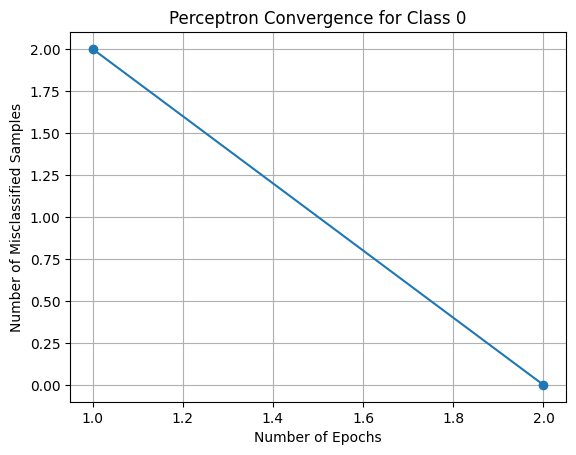

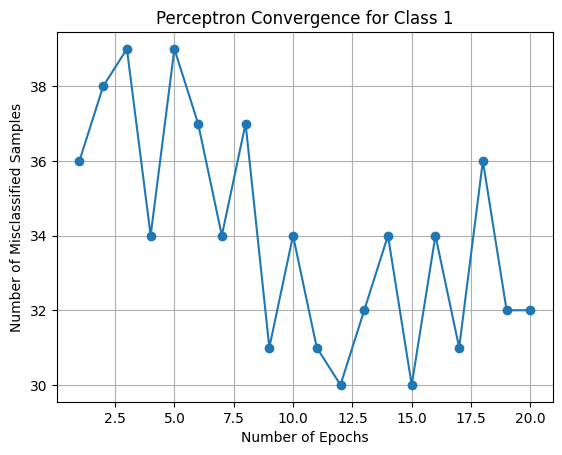

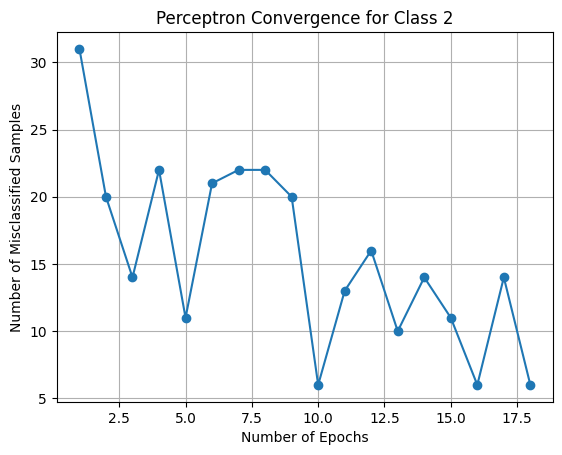

In [23]:
for class_label, misclassifications in error_history.items():

    epochs = range(1, len(misclassifications) + 1)

    plt.figure()
    plt.plot(epochs, misclassifications, marker='o')

    plt.xlabel("Number of Epochs")
    plt.ylabel("Number of Misclassified Samples")
    plt.title(f"Perceptron Convergence for Class {class_label}")

    plt.grid(True)
    plt.show()


5.  Generate the predictions on the test set, and report the accuracy, precision and recall performances. (2 Marks)

In [25]:
for cls, model in trained_models.items():
    print(f"Weights learned for class {cls}: {model.weights}")


Weights learned for class 0: [ 0.    0.39 -0.45 -0.24  0.  ]
Weights learned for class 1: [  5.1  -13.02   5.4  -13.62   5.7 ]
Weights learned for class 2: [-10.98  -5.94  13.77  16.35  -8.1 ]


In [26]:
y_pred_test = []

for x in X_test:
    activation_scores = {}

    for cls, model in trained_models.items():
        #Append bias
        x_bias = np.append(x, 1)

        #Raw activation
        score = np.dot(model.weights, x_bias)

        activation_scores[cls] = score

    #Winner = class with maximum activation
    predicted_label = max(activation_scores, key=activation_scores.get)
    y_pred_test.append(predicted_label)


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f"Accuracy: {accuracy}")
print(f"Precision (macro): {precision}")
print(f"Recall (macro): {recall}")


Accuracy: 0.8222222222222222
Precision (macro): 0.8206133735545501
Recall (macro): 0.8222222222222223


6.  Generate the class predictions with sklearn’s implementation of perceptron. Compare the corresponding performance metrics (accuracy, precision, recall) with your implementation.  (5 Marks)

In [42]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score

sk_model = Perceptron(max_iter=1000, eta0=0.01, random_state=42)

sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
sklearn_precision = precision_score(y_test, y_pred_sklearn, average='macro', zero_division=0)
sklearn_recall = recall_score(y_test, y_pred_sklearn, average='macro', zero_division=0)


In [30]:
print("Sklearn Perceptron Performance:")
print(f"Accuracy: {sklearn_accuracy}")
print(f"Precision: {sklearn_precision}")
print(f"Recall: {sklearn_recall}")

print("\nCustom Perceptron Performance:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


Sklearn Perceptron Performance:
Accuracy: 0.6666666666666666
Precision: 0.44642857142857145
Recall: 0.6666666666666666

Custom Perceptron Performance:
Accuracy: 0.8222222222222222
Precision: 0.8206133735545501
Recall: 0.8222222222222223


7.  From the performances obtained, what can you conclude about the separability of the dataset? Are any of the classes linearly separable from the others? Justify your answer (1 Mark)


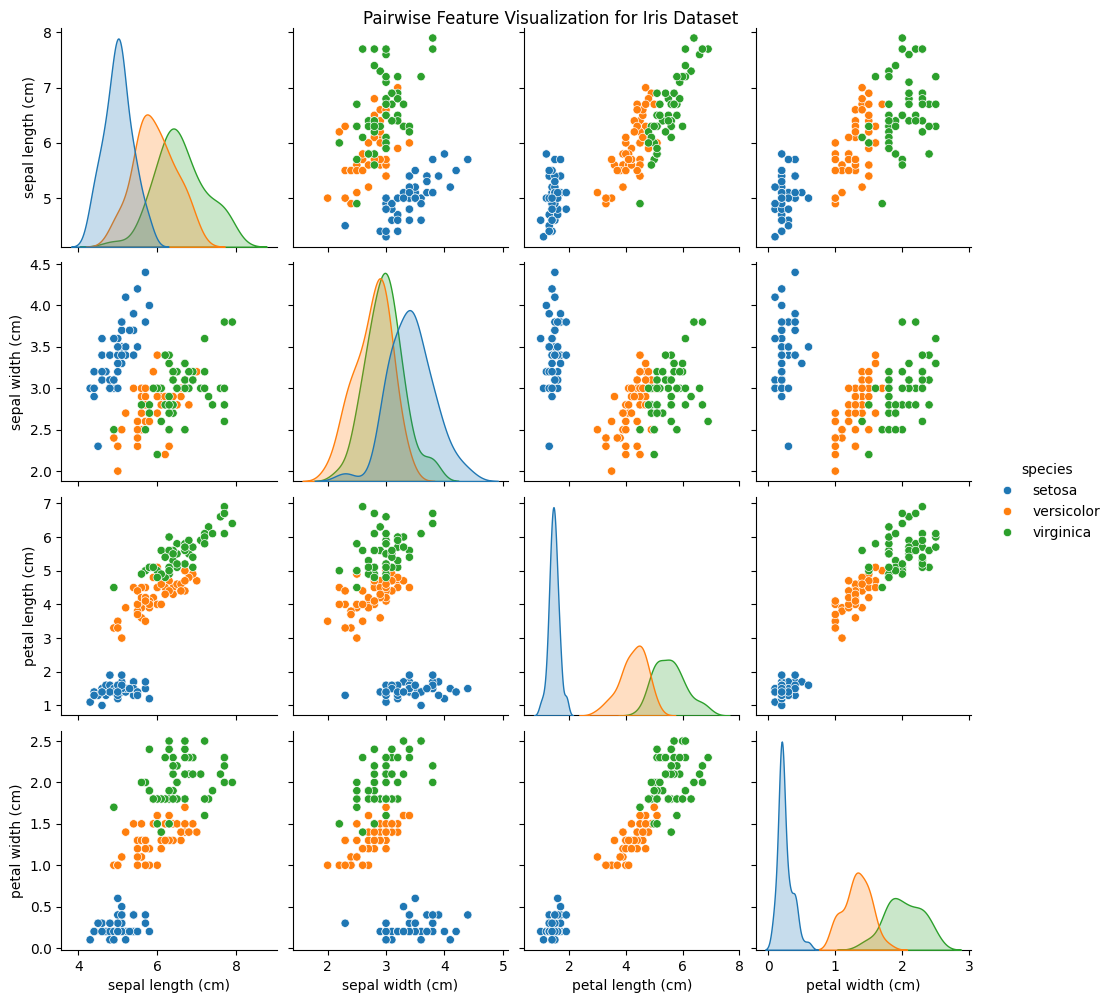

In [43]:
import seaborn as sns
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = iris.target_names[iris.target]
sns.pairplot(iris_df, hue="species", diag_kind="kde", corner=False)

plt.suptitle(
    "Pairwise Feature Visualization for Iris Dataset", y=1.0)
plt.show()